# Compare interferon-response gene sets across immune cells

**Biology rationale.** The manuscript links prostaglandin-rich signaling to suppression of interferon-associated immune activity.

**Aim.** Summarize overlaps among interferon-related gene sets and visualize shared and cell-type-specific signals.

**Data input.** `intergerongenes.csv`, `custom_IFN_HALLMARK_gene_membership_matrix.csv`, `upset_custom_IFN_vs_HALLMARK_IFN.pdf`, `upset_custom_IFN_vs_HALLMARK_IFN.png`



**Data outputs.** Processed objects, statistical summaries, and visualizations generated in the notebook.

## 1. Read IFN/interferon gene signatures from CSV


In [1]:
# ------------------------------------------------------------
# Read IFN/interferon gene signatures from CSV
# Each column = one signature
# Column name = signature name
# Non-empty values in that column = genes
# ------------------------------------------------------------

ifn_gene_df <- read.csv(
  "intergerongenes.csv",
  header = TRUE,
  stringsAsFactors = FALSE,
  check.names = FALSE
)

custom_ifn_gene_sets <- lapply(ifn_gene_df, function(genes) {
  genes <- trimws(as.character(genes))
  genes <- genes[!is.na(genes) & genes != ""]
  unique(genes)
})

# Optional checks
names(custom_ifn_gene_sets)
str(custom_ifn_gene_sets)

custom_ifn_gene_sets 
# Keep one-gene sets because TNK_IFNAB_SPECIFIC and TNK_IFNG_SPECIFIC are biologically intentional.
custom_ifn_gene_sets <- custom_ifn_gene_sets[lengths(custom_ifn_gene_sets) >= 1]

message("Custom IFN gene sets retained:")
print(sapply(custom_ifn_gene_sets, length))

[1] "REACTOME_INTERFERON_ALPHA_BETA_SIGNALING"
[2] "REACTOME_INTERFERON_GAMMA_SIGNALING"     
[3] "BIOCARTA_IFNA_PATHWAY"                   
[4] "BIOCARTA_IFNG_PATHWAY"

List of 4
 $ REACTOME_INTERFERON_ALPHA_BETA_SIGNALING: chr [1:78] "ABCE1" "ADAR" "BST2" "EGR1" ...
 $ REACTOME_INTERFERON_GAMMA_SIGNALING     : chr [1:98] "B2M" "CAMK2A" "CAMK2B" "CAMK2D" ...
 $ BIOCARTA_IFNA_PATHWAY                   : chr [1:9] "IFNA1" "IFNAR1" "IFNAR2" "IFNB1" ...
 $ BIOCARTA_IFNG_PATHWAY                   : chr [1:6] "IFNG" "IFNGR1" "IFNGR2" "JAK1" ...


$REACTOME_INTERFERON_ALPHA_BETA_SIGNALING
 [1] "ABCE1"   "ADAR"    "BST2"    "EGR1"    "EIF2AK2" "GBP2"    "HLA-A"  
 [8] "HLA-B"   "HLA-C"   "HLA-E"   "HLA-F"   "HLA-G"   "HLA-H"   "IFI27"  
[15] "IFI35"   "IFI6"    "IFIT1"   "IFIT2"   "IFIT3"   "IFIT5"   "IFITM1" 
[22] "IFITM2"  "IFITM3"  "IFNA1"   "IFNA10"  "IFNA13"  "IFNA14"  "IFNA16" 
[29] "IFNA17"  "IFNA2"   "IFNA21"  "IFNA4"   "IFNA5"   "IFNA6"   "IFNA7"  
[36] "IFNA8"   "IFNAR1"  "IFNAR2"  "IFNB1"   "IP6K2"   "IRF1"    "IRF2"   
[43] "IRF3"    "IRF4"    "IRF5"    "IRF6"    "IRF7"    "IRF8"    "IRF9"   
[50] "ISG15"   "ISG20"   "JAK1"    "KPNA1"   "KPNB1"   "MX1"     "MX2"    
[57] "OAS1"    "OAS2"    "OAS3"    "OASL"    "PSMB8"   "PTPN1"   "PTPN11" 
[64] "PTPN6"   "RNASEL"  "RPS27A"  "RSAD2"   "SAMHD1"  "SOCS1"   "SOCS3"  
[71] "STAT1"   "STAT2"   "TYK2"    "UBA52"   "UBB"     "UBC"     "USP18"  
[78] "XAF1"   

$REACTOME_INTERFERON_GAMMA_SIGNALING
 [1] "B2M"      "CAMK2A"   "CAMK2B"   "CAMK2D"   "CAMK2G"   "CD44"    
 [7] "CIITA"    "FCGR1A"   "FCGR1BP"  "GBP1"     "GBP2"     "GBP3"    
[13] "GBP4"     "GBP5"     "GBP6"     "GBP7"     "HLA-A"    "HLA-B"   
[19] "HLA-C"    "HLA-DPA1" "HLA-DPB1" "HLA-DQA1" "HLA-DQA2" "HLA-DQB1"
[25] "HLA-DQB2" "HLA-DRA"  "HLA-DRB1" "HLA-DRB3" "HLA-DRB4" "HLA-DRB5"
[31] "HLA-E"    "HLA-F"    "HLA-G"    "HLA-H"    "ICAM1"    "IFI30"   
[37] "IFNG"     "IFNGR1"   "IFNGR2"   "IRF1"     "IRF2"     "IRF3"    
[43] "IRF4"     "IRF5"     "IRF6"     "IRF7"     "IRF8"     "IRF9"    
[49] "JAK1"     "JAK2"     "MAPK1"    "MAPK3"    "MID1"     "MT2A"    
[55] "NCAM1"    "OAS1"     "OAS2"     "OAS3"     "OASL"     "PIAS1"   
[61] "PML"      "PRKCD"    "PTAFR"    "PTPN1"    "PTPN11"   "PTPN2"   
[67] "PTPN6"    "RAF1"     "SMAD7"    "SOCS1"    "SOCS3"    "SP100"   
[73] "STAT1"    "SUMO1"    "TRIM10"   "TRIM14"   "TRIM17"   "TRIM2"   
[79] "TRIM21"   "TRIM22"   "TRIM25"   "TRIM26"   "TRIM29"   "TRIM3"   
[85] "TRIM31"   "TRIM34"   "TRIM35"   "TRIM38"   "TRIM45"   "TRIM46"  
[91] "TRIM48"   "TRIM5"    "TRIM6"    "TRIM62"   "TRIM68"   "TRIM8"   
[97] "VCAM1"    "YBX1"    

$BIOCARTA_IFNA_PATHWAY
[1] "IFNA1"  "IFNAR1" "IFNAR2" "IFNB1"  "IRF9"   "JAK1"   "STAT1"  "STAT2" 
[9] "TYK2"  

$BIOCARTA_IFNG_PATHWAY
[1] "IFNG"   "IFNGR1" "IFNGR2" "JAK1"   "JAK2"   "STAT1"

Custom IFN gene sets retained:



REACTOME_INTERFERON_ALPHA_BETA_SIGNALING 
                                      78 
     REACTOME_INTERFERON_GAMMA_SIGNALING 
                                      98 
                   BIOCARTA_IFNA_PATHWAY 
                                       9 
                   BIOCARTA_IFNG_PATHWAY 
                                       6 



Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.
ℹ The deprecated feature was likely used in the ComplexUpset package.
  Please report the issue at
  <https://github.com/krassowski/complex-upset/issues>.”


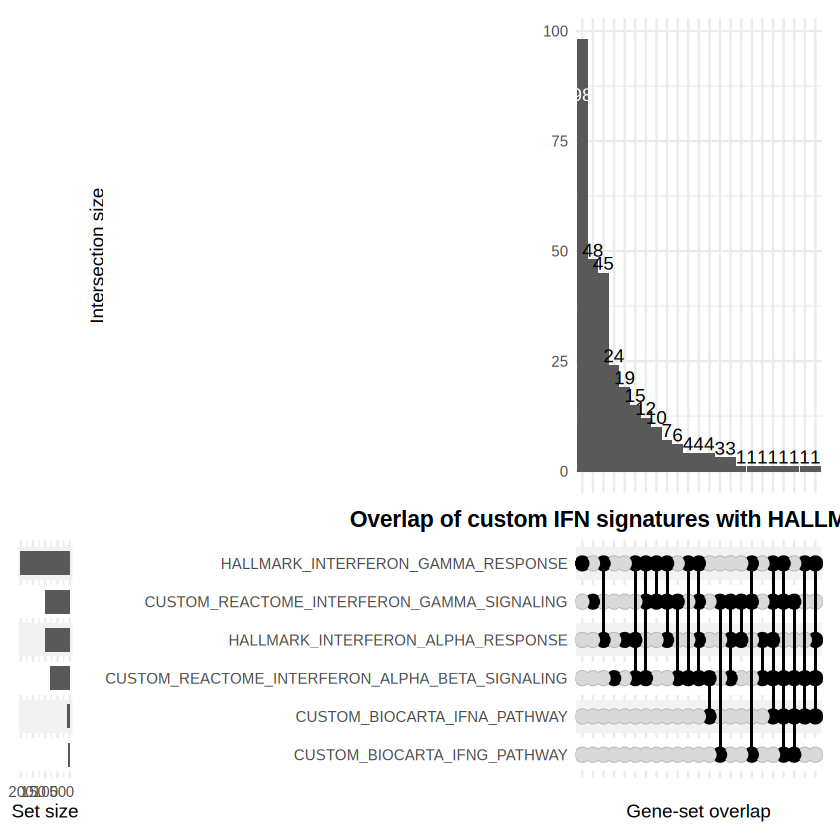

In [2]:
# ============================================================
# UpSet plot: overlap between custom IFN signatures and HALLMARK IFN sets
# ============================================================

library(msigdbr)
library(dplyr)
library(tidyr)
library(readr)
library(ggplot2)
library(ComplexUpset)

out_dir_upset <- "./results/custom_IFN_HALLMARK_overlap"
dir.create(out_dir_upset, recursive = TRUE, showWarnings = FALSE)

# Save full custom gene sets before object-specific filtering
custom_ifn_gene_sets_full <- custom_ifn_gene_sets 

# ------------------------------------------------------------
# 1) Get HALLMARK IFN alpha/gamma gene sets
# ------------------------------------------------------------
hallmark_ifn_df <- msigdbr::msigdbr(
  species = "Homo sapiens",
  category = "H"
) %>%
  dplyr::filter(gs_name %in% c(
    "HALLMARK_INTERFERON_ALPHA_RESPONSE",
    "HALLMARK_INTERFERON_GAMMA_RESPONSE"
  )) %>%
  dplyr::select(gs_name, gene_symbol) %>%
  dplyr::distinct()

hallmark_ifn_sets <- split(
  hallmark_ifn_df$gene_symbol,
  hallmark_ifn_df$gs_name
)

hallmark_ifn_sets <- lapply(hallmark_ifn_sets, unique)

# ------------------------------------------------------------
# 2) Combine custom and HALLMARK gene sets
# ------------------------------------------------------------
gene_sets_for_upset <- c(
  paste0_custom = NULL
)

gene_sets_for_upset <- c(
  setNames(custom_ifn_gene_sets_full, paste0("CUSTOM_", names(custom_ifn_gene_sets_full))),
  hallmark_ifn_sets
)

gene_sets_for_upset <- lapply(gene_sets_for_upset, function(x) {
  sort(unique(as.character(x[!is.na(x) & x != ""])))
})

# Optional: remove empty sets
gene_sets_for_upset <- gene_sets_for_upset[lengths(gene_sets_for_upset) > 0]

# ------------------------------------------------------------
# 3) Build gene-by-signature membership table
# ------------------------------------------------------------
all_genes <- sort(unique(unlist(gene_sets_for_upset)))

upset_df <- data.frame(
  gene = all_genes,
  stringsAsFactors = FALSE
)

for (nm in names(gene_sets_for_upset)) {
  upset_df[[nm]] <- upset_df$gene %in% gene_sets_for_upset[[nm]]
}

set_cols <- setdiff(colnames(upset_df), "gene")

# Save full membership matrix
readr::write_csv(
  upset_df,
  file.path(out_dir_upset, "custom_IFN_HALLMARK_gene_membership_matrix.csv")
)

# ------------------------------------------------------------
# 4) UpSet plot
# ------------------------------------------------------------
p_upset <- ComplexUpset::upset(
  upset_df,
  intersect = set_cols,
  name = "Gene-set overlap",
  min_size = 1,
  width_ratio = 0.18,
  base_annotations = list(
    "Intersection size" = ComplexUpset::intersection_size(counts = TRUE)
  )
) +
  ggplot2::ggtitle("Overlap of custom IFN signatures with HALLMARK IFN gene sets") +
  ggplot2::theme(
    plot.title = ggplot2::element_text(hjust = 0.5, face = "bold")
  )

ggplot2::ggsave(
  file.path(out_dir_upset, "upset_custom_IFN_vs_HALLMARK_IFN.pdf"),
  p_upset,
  width = 13,
  height = 7,
  useDingbats = FALSE
)

ggplot2::ggsave(
  file.path(out_dir_upset, "upset_custom_IFN_vs_HALLMARK_IFN.png"),
  p_upset,
  width = 13,
  height = 7,
  dpi = 300
)

p_upset